# 03 · Purchase-Propensity Model & Explainability

**Question:** for a customer who bought in the last 365 days, how likely is at least one purchase in the next 90 days?

The model is trained by `python -m src.propensity`; this notebook reads its saved outputs (`models/metrics.json`,
`models/propensity.joblib`, `marts.customer_propensity`) so every number shown here is the number in the report.
Scores are **model-estimated propensities** - associations with observed behaviour, not causes.

In [1]:
import os, sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import pandas as pd
from IPython.display import Image, display
from src.config import path
from src.db import connect

m = json.loads((path("models_dir") / "metrics.json").read_text(encoding="utf-8"))
pd.set_option("display.float_format", "{:.3f}".format)
print("chosen model:", m["chosen_model"], "| threshold:", round(m["threshold"], 3),
      "| calibration applied:", m["calibration"]["applied"])

chosen model: lightgbm | threshold: 0.34 | calibration applied: False


## 1 · Time-based design
Train = stacked monthly cutoffs; valid and test are later single cutoffs. Each label window ends (exclusive) on or
before the next split's cutoff, so no future information crosses a split.

In [2]:
pd.DataFrame(m["splits"]).T

,first_cutoff,last_label_end
train,2010-06-01,2011-05-30
valid,2011-06-01,2011-08-30
test,2011-09-01,2011-11-30


## 2 · Model selection on validation
Baselines first (recency rule, logistic regression), then LightGBM. LightGBM is kept only if it beats logistic
regression on **validation** ROC-AUC by the configured margin.

In [3]:
print("logistic regression C:", m["logreg_best_C"])
print("valid ROC-AUC gain, LightGBM vs logistic:", round(m["valid_auc_gain_lgbm_vs_logreg"], 4))
pd.DataFrame(m["lgbm_grid"])

logistic regression C: 1.0
valid ROC-AUC gain, LightGBM vs logistic: 0.008


,num_leaves,min_child_samples,best_iteration,valid_roc_auc
0,15,50,353,0.814
1,15,200,347,0.814
2,31,50,212,0.814
3,31,200,195,0.813
4,63,50,166,0.812
5,63,200,172,0.812


## 3 · Results - valid (selection) and test (scored once)

In [4]:
top = [k for k in m["results"]["test"][m["chosen_model"]] if k.startswith("precision_at_top")][0]
cols = ["roc_auc", "pr_auc", top, "brier", "ece", "mean_predicted", "prevalence", "precision", "recall", "f1"]
rows = [{"split": s, "model": name, **{c: r.get(c) for c in cols}}
        for s in ("valid", "test") for name, r in m["results"][s].items()]
pd.DataFrame(rows).set_index(["split", "model"])

roc_auc  pr_auc  precision_at_top20  brier   ece  \
split model                                                                   
valid recency_rule           0.746   0.592               0.661    NaN   NaN   
      logistic_regression    0.806   0.746               0.788  0.166 0.038   
      lightgbm               0.814   0.755               0.803  0.162 0.024   
test  recency_rule           0.708   0.680               0.757    NaN   NaN   
      logistic_regression    0.770   0.791               0.874  0.200 0.082   
      lightgbm               0.767   0.789               0.880  0.207 0.106   

                           mean_predicted  prevalence  precision  recall    f1  
split model                                                                     
valid recency_rule                    NaN       0.366      0.512   0.823 0.631  
      logistic_regression           0.343       0.366      0.612   0.741 0.670  
      lightgbm                      0.355       0.366      0.662   0.692 0.677  
test  recency_rule                    NaN       0.495      0.613   0.775 0.685  
      logistic_regression           0.577       0.495      0.510   0.989 0.673  
      lightgbm                      0.599       0.495      0.525   0.967 0.681

In [5]:
ci = m["test_bootstrap"]
print(f"Test ROC-AUC 95% CI {ci['roc_auc_95ci']}, PR-AUC 95% CI {ci['pr_auc_95ci']}")
cm = m["results"]["test"][m["chosen_model"]]["confusion"]
pd.DataFrame([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]],
             index=["actual: no purchase", "actual: purchase"],
             columns=["predicted: no purchase", "predicted: purchase"])

Test ROC-AUC 95% CI [0.7512239108948194, 0.7793208880759618], PR-AUC 95% CI [0.7724781329440689, 0.8028852738871085]


,predicted: no purchase,predicted: purchase
actual: no purchase,310,1872
actual: purchase,70,2072


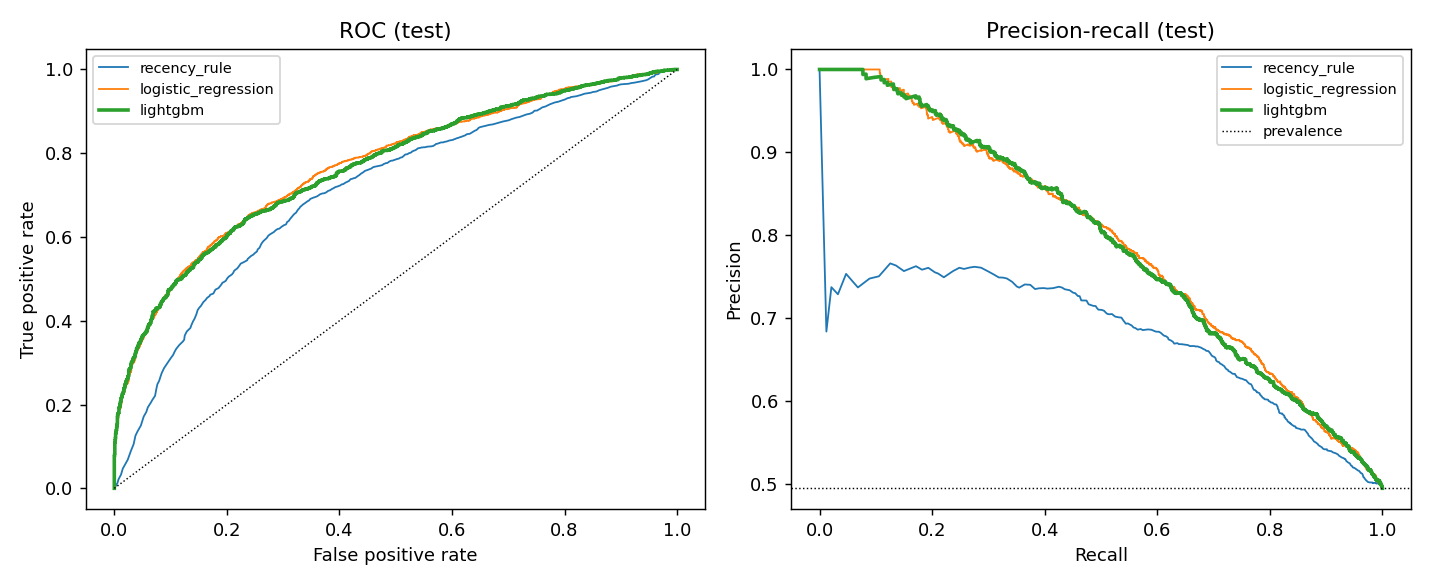

In [6]:
display(Image(filename=str(path("reports_dir") / "figures" / "step6_roc_pr_test.png")))

## 4 · Calibration and seasonality
Validation (Jun-Aug) is off-season; test (Sep-Nov) is peak season. The calendar feature
`label_window_peak_share` tells the model how much of the future window is peak season - it is known at the
cutoff, so it is not leakage. The ablation shows what happens to the probability level without it.

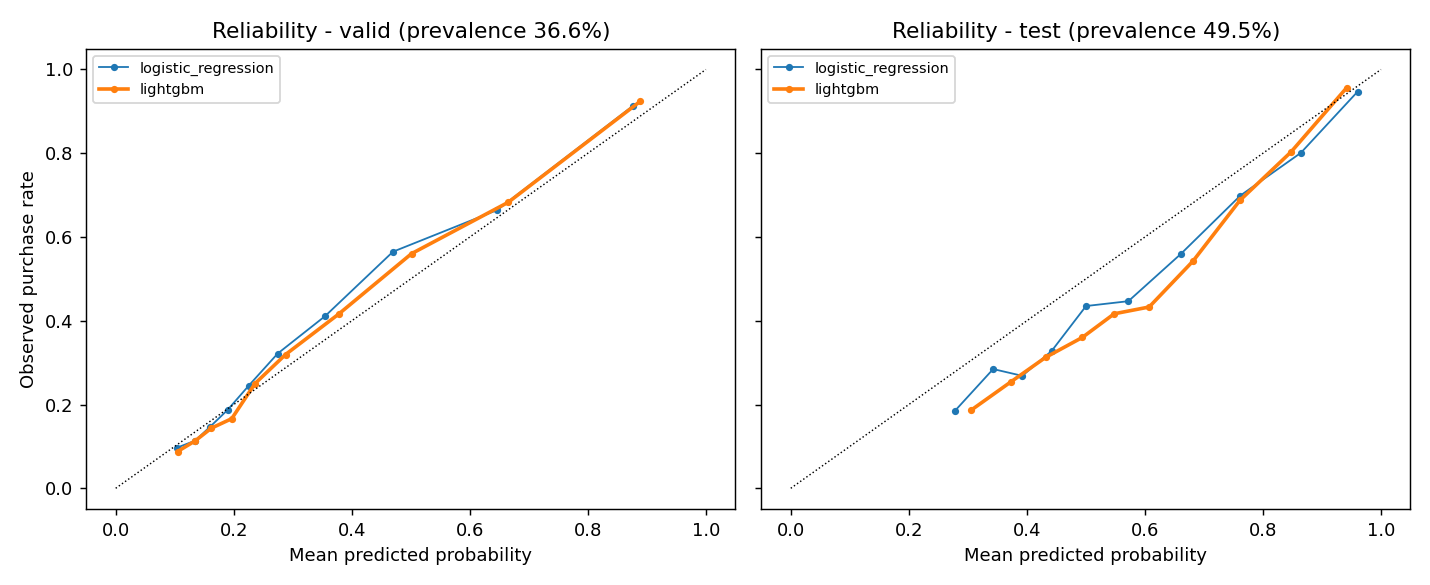

In [7]:
display(Image(filename=str(path("reports_dir") / "figures" / "step6_calibration.png")))

In [8]:
pd.DataFrame(m["ablation_test"]).T

,roc_auc,pr_auc,brier,ece,mean_predicted,prevalence
lightgbm_with_calendar,0.767,0.789,0.207,0.106,0.599,0.495
lightgbm_without_calendar,0.761,0.788,0.202,0.085,0.410,0.495


## 5 · Subgroup audit (country is audit-only, never a model input)
Descriptive only. A gap in recall or calibration at the same threshold would mean the score serves one group worse.

In [9]:
pd.DataFrame(m["audit_test"]).T

,n,prevalence,mean_predicted,roc_auc,pr_auc,selection_rate,recall,precision,false_positive_rate
UK,3937.000,0.493,0.597,0.765,0.787,0.909,0.965,0.523,0.854
International,387.000,0.525,0.621,0.777,0.813,0.946,0.985,0.546,0.902


## 6 · Current scores in the warehouse
`marts.customer_propensity` holds the score for every active customer at the scoring cutoff. Here it is joined
to the Step 5 segments in SQL.

In [10]:
con = connect(read_only=True)
seg_cols = con.execute("SELECT column_name FROM information_schema.columns "
                       "WHERE table_schema = 'marts' AND table_name = 'customer_segments'").df()["column_name"].tolist()
name_col = next(c for c in seg_cols if "name" in c)
con.execute(f'''
    SELECT s.{name_col}                            AS segment,
           COUNT(*)                                AS customers,
           ROUND(AVG(p.propensity_90d), 3)         AS avg_propensity_90d,
           ROUND(AVG(p.predicted_buyer), 3)        AS share_flagged,
           SUM(CASE WHEN p.propensity_decile >= 9 THEN 1 ELSE 0 END) AS in_top_20pct
    FROM marts.customer_propensity p
    INNER JOIN marts.customer_segments s USING (customer_id)
    GROUP BY 1
    ORDER BY avg_propensity_90d DESC
''').df()

,segment,customers,avg_propensity_90d,share_flagged,in_top_20pct
0,Core high-value repeat accounts,1071,0.738,0.994,771.000
1,Recent seasonal buyers,1354,0.325,0.405,55.000
2,High-cancellation accounts,115,0.283,0.296,3.000
3,Lapsed buyers,1234,0.257,0.203,16.000
4,Low-spend occasional buyers,487,0.209,0.113,7.000


In [11]:
con.execute('''
    SELECT propensity_decile, COUNT(*) AS customers,
           ROUND(MIN(propensity_90d), 3) AS min_p, ROUND(MAX(propensity_90d), 3) AS max_p
    FROM marts.customer_propensity
    GROUP BY 1 ORDER BY 1 DESC
''').df()

,propensity_decile,customers,min_p,max_p
0,10,426,0.818,0.983
1,9,426,0.612,0.818
2,8,426,0.490,0.612
3,7,426,0.387,0.490
4,6,426,0.307,0.387
5,5,426,0.251,0.307
6,4,426,0.214,0.251
7,3,426,0.181,0.214
8,2,426,0.148,0.181
9,1,427,0.062,0.148


In [12]:
con.close()

## 7 · Explainability
*Added in Step 7: SHAP (global and per-customer) and permutation importance, grouped by feature family,
worded as associations.*